#### **Bidirectional RNN**

1.  A Bidirectional RNN is a special kind of RNN that processes the text in both forward and backward direction.

Left → Right

Right → Left

2.  It helps the model to understand the context from both past and future words.


Ex:-- The movie was not good.

  Context:--  
  
    While predicting the meaning of "not", future words such as "good" is also important. Bidirectional RNN captures this information.

    Here the bidirectional RNN is most important.


#### **Architecture of Bidirectional RNN**


                  Input

                   ↓

              Embedding Layer

                   ↓

              Bidirectional RNN

                   ↓

                Dense Layer

                   ↓

                  Output

#### **Dataset Description:**

1.  The imdb movie review dataset contains all the movie reviews .

2.  It has around 50000 movie reviews.

3.  Out of which 25000 training labels are there and 25000 testing labels are there.

4.  The output categories for the movie labels are

    (a.)  0 ------->  Negative reviews

    (b.)  1 ------->  Positive reviews

#### **Steps used in this Algorithm:**

1.  Import all the necessary libraries

2.  Load  the dataset

3.  Understand the sequence lengths of the imdb movie review datasets

4.  Perform the padding sequence on the input

5.  Build the Bidirectional RNN Model

6.  Compile the Bidirectional RNN Model

7.  Give the summary of the model

8.  Train the model

9.  Evaluate the model

10. Plot the training accuracy and loss curve

11. Make the predictions of the model

12. Provide the predictions on the custom text data

#### **Step 1: Import all the necessary libraries**

In [242]:
import  numpy              as    np
import  pandas             as    pd
import  matplotlib.pyplot  as   plt
import  seaborn            as   sns

from    tensorflow.keras.datasets               import  imdb
from    tensorflow.keras.preprocessing.sequence import  pad_sequences
from    tensorflow.keras.models                 import  Sequential
from    tensorflow.keras.layers                 import  Dense, Dropout, Flatten, BatchNormalization
from    tensorflow.keras.layers                 import  SimpleRNN, Bidirectional, Embedding,LSTM

#### **OBSERVATIONS:**

1.  imdb ------>  It is an imdb movie review dataset that has 50000 labelled movie reviews.

2.  pad_sequences ------>  It performs the padding on the input sequence to make all the sequences of equal length.

3.  Sequential ---------> It forms a sequential model layer by layer

4.  Dense --------------> It forms a fully dense connected layer

5.  Dropout ------------> It helps in reducing the overfitting.

6.  Flatten ------------> It converts the 2d or 3d feature maps into 1 dimensional vectors.

7.  BatchNormalization -----> It stabilizes the model and speeds up the training process.

8.  Embedding  ------------> It forms an embedding layer of RNN by converting the integer encoded words into the dense dimensional vectors.

9.  SimpleRNN ----------->

    (a.)  It accepts the text as an input

    (b.)  extracts each word from the text and then processes each word

    (c.)  this goes on word by word from left to right in the forward direction

    (d.)  Then it captures the context of the entire sentence.


10.  BidirectionalRNN ------>

    (a.) It helps in processing of the information both in the forward and in the backward direction.

    (b.) It accepts each word from the text, captures the meaning of each word by capturing and referring to the meaning of the previous and the future words in the sentence.

    (c.) In this way, we can know the context behind the entire sentence completely.

11. LSTM ----------->

    (a.) It is used to remember the information for a longer period of time.

    (b.) It is used to avoid the problem of Vanishing Gradient Descent.

#### **Step 2: Load  the dataset**

In [243]:
#### Load the dataset

#### define the size of the vocabulary
vocab_size=10000

#### Load the dataset by keeping only the top 10000 words
(X_train, Y_train), (X_test, Y_test) = imdb.load_data(num_words=vocab_size)

In [244]:
X_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [245]:
X_test

array([list([1, 591, 202, 14, 31, 6, 717, 10, 10, 2, 2, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 2, 38, 32, 25, 7944, 451, 202, 14, 6, 717]),
       list([1, 14, 22, 3443, 6, 176, 7, 5063, 88, 12, 2679, 23, 1310, 5, 109, 943, 4, 114, 9, 55, 606, 5, 111, 7, 4, 139, 193, 273, 23, 4, 172, 270, 11, 7216, 2, 4, 8463, 2801, 109, 1603, 21, 4, 22, 3861, 8, 6, 1193, 1330, 10, 10, 4, 105, 987, 35, 841, 2, 19, 861, 1074, 5, 1987, 2, 45, 55, 221, 15, 670, 5304, 526, 14, 1069, 4, 405, 5, 2438, 7, 27, 85, 108, 131, 4, 5045, 5304, 3884, 405, 9, 3523, 133, 5, 50, 13, 104, 51, 66, 166, 14, 22, 157, 9, 4, 530, 239, 34, 8463, 2801, 45, 407, 31, 7, 41, 3778, 105, 21, 59, 299, 12, 38, 950, 5, 4521, 15, 45, 629, 488, 2733, 127, 6, 52, 292, 17, 4, 6936, 185, 132, 1988, 5304, 1799, 488, 2693, 47, 6, 392, 173, 4, 2, 4378, 270, 2352, 4, 1500, 7, 

In [246]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (25000,)
Shape of the input testing  data is: (25000,)


In [247]:
Y_train

array([1, 0, 0, ..., 0, 1, 0])

In [248]:
Y_test

array([0, 1, 1, ..., 0, 0, 0])

In [249]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (25000,)
Shape of the output testing  data is: (25000,)


#### **OBSERVATIONS:**

1.  The imdb movie review dataset is loaded that contains top 10000 most frequent words.

2.  The imdb movie review dataset has 50000 movie labelled reviews.

3.  Then the review dataset is divided into the training and testing data.

4.  The imdb movie training data has 25000 labelled reviews

5.  The imdb movie testing  data has 25000 labelled reviews.

#### **Step 3: Understand the sequence lengths of the imdb movie review datasets**

In [250]:
#### Understand the sequence length of all the imdb movie reviews
review_lengths = [len(review) for review in X_train[:1000]]

print("Average length of all the imdb movie reviews:", np.mean(review_lengths))
print("Maximum length of all the imdb movie reviews:", np.max(review_lengths))

Average length of all the imdb movie reviews: 243.901
Maximum length of all the imdb movie reviews: 1038


#### **Step 4: Perform the padding sequence on the input**

In [251]:
#### Check the shape of the input data before padding
print("Shape of the input training data before padding:", X_train.shape)
print("Shape of the input testing  data before padding:", X_test.shape)

Shape of the input training data before padding: (25000,)
Shape of the input testing  data before padding: (25000,)


In [252]:
#### perform the padding on the input sequences
max_length=200
#### perform the padding on the inputs
X_train = pad_sequences(X_train, maxlen = max_length)
X_test  = pad_sequences(X_test,  maxlen = max_length)

In [253]:
X_train

array([[   5,   25,  100, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]], dtype=int32)

In [254]:
X_test

array([[   0,    0,    0, ...,   14,    6,  717],
       [1987,    2,   45, ...,  125,    4, 3077],
       [4468,  189,    4, ...,    9,   57,  975],
       ...,
       [   0,    0,    0, ...,   21,  846, 5518],
       [   0,    0,    0, ..., 2302,    7,  470],
       [   0,    0,    0, ...,   34, 2005, 2643]], dtype=int32)

#### **OBSERVATIONS:**

1. Maximum input sequence is considered to be 200.

2. The padding operation is performed on the input training and testing data.

3. This is because

    (a.)  Initially the input training and testing data has integer encoded words.

    (b.) Each word is of the different length sequence.

    (c.) So padding is performed on the input training and testing sequence to make all the sequences of the equal length.

4. Padding is done as RNN accepts all the input sequences to be of the same length.

In [255]:
#### Check the shape of the input data after padding
print("Shape of the input training data after padding:",  X_train.shape)
print("Shape of the input testing  data after padding:",  X_test.shape)

Shape of the input training data after padding: (25000, 200)
Shape of the input testing  data after padding: (25000, 200)


#### **OBSERVATIONS:**

1.  Here all the inpuyt training and testing data are of the equal length sequence of 200.

#### **Step 5: Build the Bidirectional RNN Model**

#### **(a.)  Bidirectional RNN with SimpleRNN Model**

In [256]:
#### Build the bidirectional RNN with SimpleRNN

bidirectional_simplernn_model = Sequential([
    #### create an embedding layer
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length)            ,
    #### create a bidirectional layer on top of embedding layer
    Bidirectional(SimpleRNN(units=64))                                                  ,
    #### Add a dropout layer to avoid the overfitting
    Dropout(0.5)                                                                        ,
    #### Add a dense layer
    Dense(units=64, activation='relu')                                                  ,
    #### Add a dropout layer
    Dropout(0.5)                                                                        ,
    #### Add an output layer with sigmoid activation function applied on it
    Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [257]:
bidirectional_simplernn_model

<Sequential name=sequential_13, built=False>

#### **(b.)  Bidirectional RNN with LSTM Model**

In [258]:
#### Build the bidirectional RNN with LSTM

bidirectional_lstm_model = Sequential([
    #### create an embedding layer
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length)            ,
    #### create a bidirectional layer on top of embedding layer
    Bidirectional(LSTM(units=64))                                                  ,
    #### Add a dropout layer to avoid the overfitting
    Dropout(0.5)                                                                        ,
    #### Add a dense layer
    Dense(units=64, activation='relu')                                                  ,
    #### Add a dropout layer
    Dropout(0.5)                                                                        ,
    #### Add an output layer with sigmoid activation function applied on it
    Dense(units=1, activation='sigmoid')
])

In [259]:
bidirectional_lstm_model

<Sequential name=sequential_14, built=False>

#### **OBSEREVATIONS:**

1.  Here bidirectional model with SimpleRNN and bidirectional model with LSTM is made.

2.  In embedding we consider each word id , then it is converted into the dense dimensional vectors with the maximum lengthy of 200.

3.  Then we perform bidirectional RNN with SimpleRNN in the first case

    (a.) Here it considers each word from left ----> right and from right ---> left and understand the context of each word by referring to the previous and the forward word in the text.

4.  Then we perform bidirectional RNN with LSTM in the second case

    (a.) Here it considers each word from left ----> right and from right ---> left and understand the context of each word by referring to the previous and the forward word in the text.

    (b.) But it remebers the information about the input sequence for a long period of time.

5.  Then dropout layer is added to avoid overfitting and all the unnecessary neurons.

6.   Dense layer is added with 64 neurons with relu activation function applied on it to increase the non-linearity of the image.

7.  Then again dropout layer is added to avoid overfitting and all the unnecessary neurons.

8.  Then the output layer is created with one dense neuron and sigmoid activation function is applied on it to solve the binary classification problems.

In [260]:
#### get the summary for bidirectional with simple rnn
bidirectional_simplernn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [261]:
#### get the summary for bidirectional with lstm
bidirectional_lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### **Step 6: Compile the Bidirectional RNN Model**

In [262]:
#### compile the bidirectional_simplernn_model
bidirectional_simplernn_model.compile(
    optimizer   =   'adam'                              ,
    loss        =   'binary_crossentropy'               ,
    metrics     =   ['accuracy']
)

In [263]:
#### compile the bidirectional_lstm_model
bidirectional_lstm_model.compile(
    optimizer   =   'adam'                              ,
    loss        =   'binary_crossentropy'               ,
    metrics     =   ['accuracy']
)

#### **OBSERVATIONS:**

1.  Both the models are ready for training with the following parameters:--

    (a.) optimizer = 'adam'. It is used to update the weights during the backpropogation.

    (b.)  loss = 'binary_crossentropy' . It is used to solve the binary classification problem.

    (c.)  metrics = 'accuracy'. It isn used to evaluate the performance of the model.

#### **Step 7: Give the summary of the model**

In [264]:
#### get the summary for both the models
bidirectional_simplernn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [265]:
bidirectional_lstm_model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### **OBSERVATIONS:**

1.  It provides the summary for each of the models.

#### **Step 8: Train the model**

#### **(a.) Train the bidirectional model with SimpleRNN**

In [266]:
history1=bidirectional_simplernn_model.fit(
    X_train                                                        ,
    Y_train                                                        ,
    epochs                =             5                          ,
    batch_size            =             64                         ,
    validation_split      =             0.2                        ,
    verbose               =             1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 166ms/step - accuracy: 0.5185 - loss: 0.7000 - val_accuracy: 0.5566 - val_loss: 0.6795
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step - accuracy: 0.7099 - loss: 0.5581 - val_accuracy: 0.7290 - val_loss: 0.5421
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.8451 - loss: 0.3815 - val_accuracy: 0.8078 - val_loss: 0.4614
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.8962 - loss: 0.2715 - val_accuracy: 0.8316 - val_loss: 0.4599
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 165ms/step - accuracy: 0.9399 - loss: 0.1707 - val_accuracy: 0.8200 - val_loss: 0.5890


#### **(b.) Train the bidirectional model with LSTM**

In [267]:
history2=bidirectional_lstm_model.fit(
    X_train                                                        ,
    Y_train                                                        ,
    epochs                =             5                          ,
    batch_size            =             64                         ,
    validation_split      =             0.2                        ,
    verbose               =             1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 504ms/step - accuracy: 0.7642 - loss: 0.4681 - val_accuracy: 0.8622 - val_loss: 0.3475
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 155s 494ms/step - accuracy: 0.8982 - loss: 0.2655 - val_accuracy: 0.8774 - val_loss: 0.3002
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 533ms/step - accuracy: 0.9297 - loss: 0.1922 - val_accuracy: 0.8704 - val_loss: 0.3403
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 179s 574ms/step - accuracy: 0.9453 - loss: 0.1544 - val_accuracy: 0.8558 - val_loss: 0.3881
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 165s 528ms/step - accuracy: 0.9613 - loss: 0.1111 - val_accuracy: 0.8264 - val_loss: 0.4405


#### **OBSERVATIONS:**

1.  The both the models has been trained with the help of the following parameters:--

    (a.)  X_train, Y_train --------->  both the training data

    (b.)  epochs = 5   -------------> No of iterations to train the model is 5

    (c.)  batch_Size = 64 --------->  Total 64 units to be considered in a batch for model training

    (d.)  validation_split = 0.2 ------> 20 % of the validation data means it allows the model to check its performance on the unseen data

    (e.) vervbose = 1 ----------> It controls the training output.

2. The model is trained for both the process.

3.  After the model training, the accuracy of both the models have increased  and the loss function for both the models have reduced.

4.  So the model is working fine.

#### **Step 9: Evaluate the model**

In [268]:
#### compute the loss and accuracy for the first model
loss1, acc1 = bidirectional_simplernn_model.evaluate(X_test, Y_test, verbose=0)

print(f"Loss is : {loss1:.4f}")
print(f"Accuracy is : {acc1:.4f}")

Loss is : 0.5946
Accuracy is : 0.8195


In [270]:
#### compute the loss and accuracy for the second model
loss2, acc2 = bidirectional_lstm_model.evaluate(X_test, Y_test, verbose=0)

print(f"Loss is : {loss2:.4f}")
print(f"Accuracy is : {acc2:.4f}")

Loss is : 0.4539
Accuracy is : 0.8208


**OBSERVATIONS:**

1. After evaluating the RNN Model with the test data, it is known that the test accuracy of the model is very high while the loss function is very less.

2. So the model is completely fine.

3. After evaluating both the bidirectional models, we came to the conclusion that the test accuracy for bidirectional with LSTM RNN is performing well as compared to the Simple RNN.

#### **Step 10: Plot the training accuracy and loss curve**


#### **(a.) Bidirectional with Simple RNN Model**

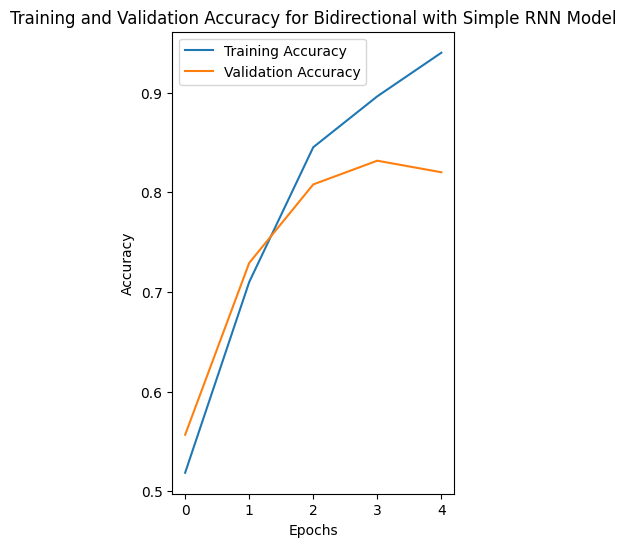

In [271]:
plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
#### plot the Training and Validation accuracy for the Simple RNN Model
plt.plot(history1.history['accuracy'],     label = 'Training Accuracy')
plt.plot(history1.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy for Bidirectional with Simple RNN Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1.  For a bidirectional RNN with Simple RNN:

    (a.)  With the increase in the number of epochs, the training and the validation accuracy of the model increases.

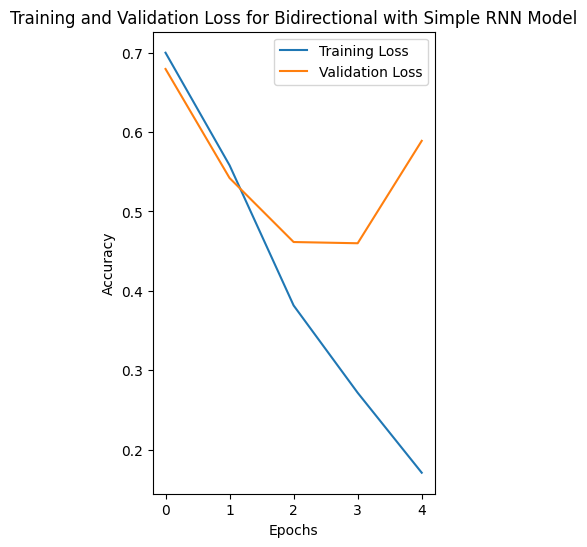

In [272]:
plt.figure(figsize=(8,6))

plt.subplot(1,2,2)
#### plot the Training and Validation loss for the Simple RNN Model
plt.plot(history1.history['loss'],         label = 'Training Loss')
plt.plot(history1.history['val_loss'],     label = 'Validation Loss')
plt.title('Training and Validation Loss for Bidirectional with Simple RNN Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1.  For a bidirectional RNN with Simple RNN:

    (a.)  With the increase in the number of epochs, the training and the validation loss of the model decreases.

#### **(b.) Bidirectional with LSTM**

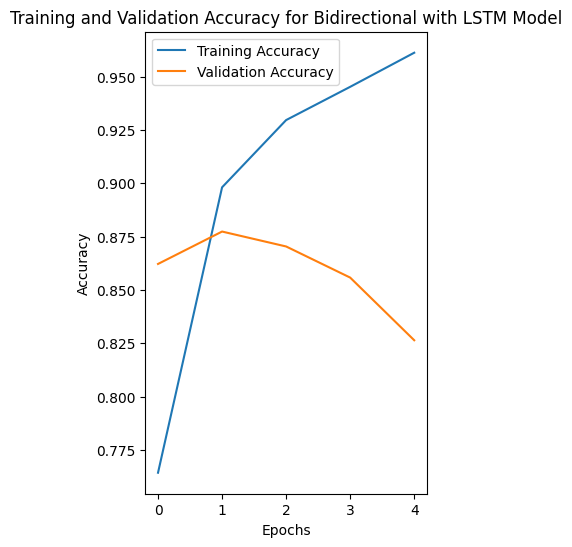

In [274]:
plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
#### plot the Training and Validation accuracy for the LSTM Model
plt.plot(history2.history['accuracy'],     label = 'Training Accuracy')
plt.plot(history2.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy for Bidirectional with LSTM Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1.  For a bidirectional RNN with LSTM:

    (a.)  With the increase in the number of epochs, the training and the validation accuracy of the model increases.

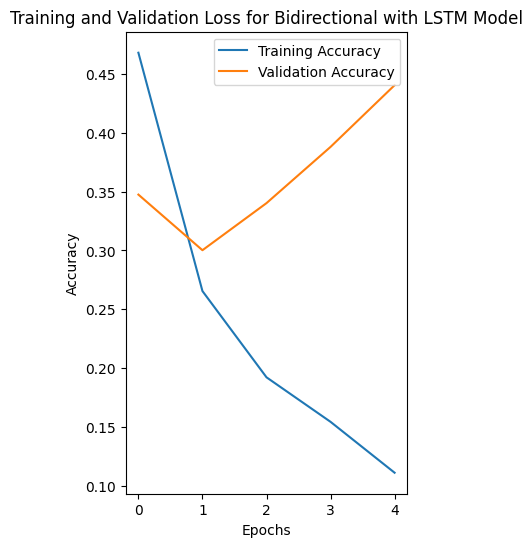

In [275]:
plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
#### plot the Training and Validation loss for the LSTM Model
plt.plot(history2.history['loss'],     label = 'Training Accuracy')
plt.plot(history2.history['val_loss'], label = 'Validation Accuracy')
plt.title('Training and Validation Loss for Bidirectional with LSTM Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1.  For a bidirectional RNN with LSTM:

    (a.)  With the increase in the number of epochs, the training and the validation loss of the model decreases.

#### **OBSERVATIONS:**

1.  This helps detect:

    (a.)  Overfitting

    (b.)  Underfitting

    (c.)  Convergence issues

#### **Step 11: Make the predictions of the model**

In [276]:
#### perform the predictions for the model
prediction1 = bidirectional_simplernn_model.predict(X_test)
print(prediction1)

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step
[[0.49875695]
 [0.99534136]
 [0.8597458 ]
 ...
 [0.03525044]
 [0.01855121]
 [0.9995399 ]]


In [277]:
prediction2 = bidirectional_lstm_model.predict(X_test)
print(prediction2)

782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step
[[0.15494233]
 [0.9955241 ]
 [0.71429366]
 ...
 [0.03258469]
 [0.01577493]
 [0.75875145]]


#### **Step 12: Provide the predictions on the custom text data**

#### **(a.) Bidirectional with SimpleRNN Model**

In [280]:
### Get the index of each and every word

word_index = imdb.get_word_index()

### define the function to encode the words into integers
def encoded_review(text):
  ### get the tokens from the text
  tokens = text.lower().split()
  ### check if the token is present in the word index dic if not then assign with 2
  encoded_text = [word_index.get(word,2) for word in tokens]
  ### perform the padding on the encoded text to make all the input sequences as equal length
  encoded_texts = pad_sequences([encoded_text],maxlen=max_length)
  return(encoded_texts)

### define the sample text
sample_text = "This movie was amazing and the actors were brilliant"

res = encoded_review(sample_text)
print(res)

### Make the predictions from the encoded data
predictions = bidirectional_simplernn_model.predict(res)[0][0]
print(predictions)

if(predictions > 0.5):
  print("Positive Review")
else:
  print("Negative Review")


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0  11  17  13 477   2   1 153
   68 527]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
0.8852626
Positive Review


#### **(b.) Bidirectional with LSTM Model**

In [281]:
### Get the index of each and every word

word_index = imdb.get_word_index()

### define the function to encode the words into integers
def encoded_review(text):
  ### get the tokens from the text
  tokens = text.lower().split()
  ### check if the token is present in the word index dic if not then assign with 2
  encoded_text = [word_index.get(word,2) for word in tokens]
  ### perform the padding on the encoded text to make all the input sequences as equal length
  encoded_texts = pad_sequences([encoded_text],maxlen=max_length)
  return(encoded_texts)

### define the sample text
sample_text = "This movie was amazing and the actors were brilliant"

res = encoded_review(sample_text)
print(res)

### Make the predictions from the encoded data
predictions = bidirectional_lstm_model.predict(res)[0][0]
print(predictions)

if(predictions > 0.5):
  print("Positive Review")
else:
  print("Negative Review")


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0  11  17  13 477   2   1 153
   68 527]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
0.07213479
Negative Review
